# 1. Project Overview

## 1.1 Business Problem

Customer reviews contain valuable information about product quality, customer satisfaction, and purchasing behavior. Before performing analytics or building machine learning models, the raw data must be understood, validated, and assessed for quality.

This notebook analyzes the Sports & Outdoors category from the Amazon Reviews 2023 dataset.

## 1.2 Dataset Objective

The objective of this notebook is to explore the Bronze layer datasets, understand their structure, validate relationships, identify data quality issues, and document the transformations required for the Silver layer.

## 1.3 Dataset Description

The Sports & Outdoors dataset consists of two Bronze layer datasets:

- Reviews Dataset
- Product Metadata Dataset

Both datasets are stored in Apache Parquet format without any modifications to the original source data.

## 1.5 Dataset Source

**Dataset:** Amazon Reviews 2023

**Provider:** McAuley Lab

The original JSONL files were converted into Apache Parquet format and stored in the Bronze layer using PySpark.

## 1.6 File Information

This notebook analyzes the following Bronze datasets:

- Sports_and_Outdoors Reviews
- meta_Sports_and_Outdoors Metadata

## 1.7 Expected Output

By the end of this notebook we will:

- Understand the dataset structure
- Validate keys and relationships
- Assess data quality
- Identify missing and duplicate records
- Generate business insights
- Recommend transformations for the Silver layer

In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

pd.set_option("display.max_columns", None)
plt.style.use("default")

In [2]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)

In [3]:
pd.set_option("display.max_colwidth", 200)

In [4]:
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["SPARK_LOCAL_HOSTNAME"] = "localhost"

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("Sports_EDA")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.driver.memory", "10g")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.ui.enabled", "false")
    .getOrCreate()
)

spark.conf.set("spark.sql.caseSensitive", "true")

In [5]:
BASE_PATH = r"C:\Users\affaa\OneDrive\Desktop\CDAC_PROJECT\Bronze"

REVIEWS_PATH = os.path.join(
    BASE_PATH,
    "reviews",
    "Sports_and_Outdoors"
)

METADATA_PATH = os.path.join(
    BASE_PATH,
    "metadata",
    "meta_Sports_and_Outdoors"
)

## 2.1 Load Reviews Dataset

Load the Sports & Outdoors customer reviews dataset from the Bronze layer.

In [6]:
reviews_df = spark.read.parquet(REVIEWS_PATH)

## 2.2 Load Metadata Dataset

Load the Sports & Outdoors product metadata dataset from the Bronze layer.

In [7]:
metadata_df = spark.read.parquet(METADATA_PATH)

## 2.3 Dataset Shape

Display the total number of rows and columns in each dataset.

In [11]:
shape_df = pd.DataFrame({
    "Dataset": ["Reviews", "Metadata"],
    "Rows": [reviews_df.count(), metadata_df.count()],
    "Columns": [len(reviews_df.columns), len(metadata_df.columns)]
})

shape_df

,Dataset,Rows,Columns
0,Reviews,19595170,10
1,Metadata,1587421,16


## 2.4 Schema

Display the schema of both datasets to understand the available columns, data types, and overall structure.

In [16]:
print("=" * 80)
print("REVIEWS DATASET SCHEMA")
print("=" * 80)

reviews_df.printSchema()

print("\n")

print("=" * 80)
print("METADATA DATASET SCHEMA")
print("=" * 80)

metadata_df.printSchema(level=1)

REVIEWS DATASET SCHEMA
root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)



METADATA DATASET SCHEMA
root
 |-- author: struct (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- bought_together: string (nullable = true)
 |-- categories: array (nullable = true)
 |-- description: array (nullable = true)
 |-- details: struct (nullable = true)
 |-- features

## 2.5 Column Description

List all columns available in the Reviews and Metadata datasets.

In [17]:
reviews_columns = pd.DataFrame({
    "Reviews Columns": reviews_df.columns
})

metadata_columns = pd.DataFrame({
    "Metadata Columns": metadata_df.columns
})

display(reviews_columns)
display(metadata_columns)

,Reviews Columns
0,asin
1,helpful_vote
2,images
3,parent_asin
4,rating
5,text
6,timestamp
7,title
8,user_id
9,verified_purchase


,Metadata Columns
0,author
1,average_rating
2,bought_together
3,categories
4,description
5,details
6,features
7,images
8,main_category
9,parent_asin


## 2.6 Data Types

Review the data type of each column to identify any datatype inconsistencies before transformation.

In [18]:
def datatype_summary(df):
    return pd.DataFrame(
        [(field.name, field.dataType.simpleString())
         for field in df.schema.fields],
        columns=["Column", "Data Type"]
    )

print("Reviews Dataset")
display(datatype_summary(reviews_df))

print("Metadata Dataset")
display(datatype_summary(metadata_df))

Reviews Dataset


,Column,Data Type
0,asin,string
1,helpful_vote,bigint
2,images,"array<struct<attachment_type:string,large_imag..."
3,parent_asin,string
4,rating,double
5,text,string
6,timestamp,bigint
7,title,string
8,user_id,string
9,verified_purchase,boolean


Metadata Dataset


,Column,Data Type
0,author,"struct<about:array<string>,avatar:string,name:..."
1,average_rating,double
2,bought_together,string
3,categories,array<string>
4,description,array<string>
5,details,"struct<ABPA Partslink Number:string,AC Adapter..."
6,features,array<string>
7,images,"array<struct<hi_res:string,large:string,thumb:..."
8,main_category,string
9,parent_asin,string


## 2.7 Memory Usage

Display the storage size of the Bronze layer datasets.

In [20]:
def folder_size(path):
    total_size = 0

    for root, dirs, files in os.walk(path):
        for file in files:
            total_size += os.path.getsize(os.path.join(root, file))

    return total_size / (1024 ** 3)
    

In [21]:
reviews_size = folder_size(REVIEWS_PATH)
metadata_size = folder_size(METADATA_PATH)

memory_df = pd.DataFrame({
    "Dataset": ["Reviews", "Metadata"],
    "Storage Size (GB)": [f"{reviews_size:.2f}", f"{metadata_size:.2f}"]
})

memory_df

,Dataset,Storage Size (GB)
0,Reviews,3.42
1,Metadata,2.92


## 2.8 First 10 Records

Display the first ten records from each dataset.

In [27]:
print("Reviews Dataset")
display(reviews_df.limit(10).toPandas())

print("Metadata Dataset")
display(metadata_df.limit(10).toPandas())

Reviews Dataset


,asin,helpful_vote,images,parent_asin,rating,text,timestamp,title,user_id,verified_purchase
0,B07HJ2HYZV,0,[],B07HJ2421X,5.0,Eyes glow well. No issues.,1616132396916,Pretty neat,AFUF6HJRQWUIGBTQNGVZYZJUW6SA,True
1,B0131SE0KI,0,[],B0131SE0KI,5.0,"I like it for day hikes. Not too big, not too small. Comfortable. No belt, which is what I wanted as I wear a battle belt with this.",1612417884731,Pretty good day pack,AFUF6HJRQWUIGBTQNGVZYZJUW6SA,True
2,B01N5O7551,0,[],B01N5O7551,5.0,Boils water fast. Fits easily in a med sized MSR pot.,1612417377014,Small and light,AFUF6HJRQWUIGBTQNGVZYZJUW6SA,True
3,B01B3NRAUA,0,[],B01B3NRAUA,5.0,"When it gets too cold for butane, this is my go to stove. Lightweight, easy to use, dirt cheap. Not as high speed/low drag as a butane stove but it boils water long after my MSR PocketRocket dies from the cold.",1612416926927,Great cold weather stove,AFUF6HJRQWUIGBTQNGVZYZJUW6SA,True
4,B07NQFFF3L,2,[],B07P5JZ4SN,5.0,A lot more stout than the others I have. Has found a home in my main hiking pack. Worth it.,1612416614001,A step above the plastic handle types,AFUF6HJRQWUIGBTQNGVZYZJUW6SA,True
5,B00AZVMDMC,0,[],B078HQ5C88,5.0,Semi rigid and fits great in my MSR med size stainless pot.,1612416445782,Nests perfect in my MSR pot,AFUF6HJRQWUIGBTQNGVZYZJUW6SA,True
6,B06XCYWNZG,0,[],B06XCYWNZG,3.0,"I installed this unit and it seems to work OK but time will tell because the unit it replaced, which appeared to be identical worked initially but then fell apart once slight stress was put upon it. So for the time being I give it three stars and will update after I’ve used it enough to know that it is going to hold up.",1523450711241,I installed this unit and it seems to work OK ...,AH24RKUNKP35GYV4XPMOFW3EWEYQ,True
7,B012EZCNTE,0,[],B012EZCNTE,4.0,I Bought this for my granddaughter. Even after reading the specifications on it I still found it to be rather large when it arrived. It does appear to be well-made and looks like it will be warm for her.,1521724195254,It does appear to be well-made and looks like it will be warm for her,AH24RKUNKP35GYV4XPMOFW3EWEYQ,True
8,B00J972O8Q,0,[],B094X5GHFT,4.0,"I would give this five stars but I haven’t used yet but the quality appears to be really nice. When I first opened it up I hadn’t even unrolled it and I inspected the two air intake valve stems, one was real easy to loosen so I could inflate with it, however the other one was so tight I could not get it loose after considerable trying. Finally, after twisting back-and-forth considerably, I was able to get it to pop in and out. Now it works fine. So, as long as there are no leaks when I am finally abke to use the pad I should be a happy camper. Afterwards I will update my rating.",1521658137826,... used yet but the quality appears to be really nice. When I first opened it up I hadn’t ...,AH24RKUNKP35GYV4XPMOFW3EWEYQ,True
9,B00MPH1LEU,0,[],B08HWP19XK,4.0,"I have not yet field tested this product. After I do, I may upgrade to 5 rating. Looking at it and testing them iver the kitchen sink seceral times leads me to believe they will work great in the field. However, I still went ahead and. Ought the Sawyer Squeeze, which has a million gallons capability rarher than the mininat 100,000 gallons.",1496523049000,Looking at it and testing them iver the kitchen sink seceral times leads me to believe they will work great in the field,AH24RKUNKP35GYV4XPMOFW3EWEYQ,False


Metadata Dataset


,author,average_rating,bought_together,categories,description,details,features,images,main_category,parent_asin,price,rating_number,store,subtitle,title,videos
0,None,3.1,None,"[Sports & Outdoors, Exercise & Fitness, Strength Training Equipment, Resistance Bands]","[The MaxFlowSports Cross-Grip hairband effectively controls your hair and manages your sweat . It's patent-pending design and Cross-Grip technology makes it extremely slip-resistant and it's ""return elasticity"" helps it to always return to form. Everyone from the professional athlete to the weekend warrior will find this to be the best hairband they've ever used.]","(None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, ...)","[Return Elasticity, High Performance, Controls your sweat]","[(None, https://m.media-amazon.com/images/I/11sRmEBaZvL._AC_.jpg, https://m.media-amazon.com/images/I/11sRmEBaZvL._AC_US40_.jpg, MAIN), (None, https://m.media-amazon.com/images/I/21uWPjz6irL._AC_.jpg, https://m.media-amazon.com/images/I/21uWPjz6irL._AC_US40_.jpg, PT01), (None, https://m.media-amazon.com/images/I/21jdQGxP-tL._AC_.jpg, https://m.media-amazon.com/images/I/21jdQGxP-tL._AC_US40_.jpg, PT02)]",NaN,B00EPVPGYA,NaN,24,MaxFlowSports,None,MaxFlowSports Cross-Grip Hairband,[]
1,None,4.0,None,"[Sports & Outdoors, Fan Shop, Clothing, Jerseys]",[],"(None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, ...)","[100% polyester material, Imported, Hand Wash Only, Decorated in full team colors with official logos, V-neck collar, High cut on stomach area for comfort fit for male dogs, Machine washable, Polyester material]","[(https://m.media-amazon.com/images/I/71RDUlyuzaL._AC_UL1500_.jpg, https://m.media-amazon.com/images/I/51KhpgRdVSL._AC_.jpg, https://m.media-amazon.com/images/I/51KhpgRdVSL._AC_SR38,50_.jpg, MAIN)]",NaN,B003WBYWQC,NaN,4,Hunter Company,None,"NCAA Florida State Seminoles Pet Jersey, X-Large",[]
2,None,5.0,None,"[Sports & Outdoors, Exercise & Fitness, Strength Training Equipment, Resistance Bands]",[These awesome rubber cuff-bands are the ultimate party accessory to show how much you and your party goers love the L.A. Lakers. Use them as prizes or party giveaways on your awesome NBA themed party.],"(None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, ...)","[PACKAGE INCLUDES: 6 Pcs.L.A. Lakers Cuff Band Favors, ADORABLE DESIGN: These awesome rubber cuff-bands a

## 2.9 Last 10 Records

Display the most recent records from the Reviews dataset and the last available records from the Metadata dataset based on the current partition ordering.

In [30]:
display(
    reviews_df
    .orderBy(col("timestamp").desc())
    .limit(10)
    .toPandas()
)

,asin,helpful_vote,images,parent_asin,rating,text,timestamp,title,user_id,verified_purchase
0,B07RDLQM7B,0,[],B08C2C8RKV,5.0,comfortable and supports your palm,1694670041162,comfortable,AHZOQB35MWVZUUJVSHGDN23JMORQ,True
1,B07DQLFVKC,0,[],B07DQDDCD1,5.0,Easy replacement for organic pads everything is included. 3 minutes to install.,1694573980820,"Great organic replacement pads easy install, I will buy more.",AE3WXEPZXAOEHCWSRTFVPCY7RWCQ,True
2,B07DQLFVKC,0,[],B07DQDDCD1,5.0,Easy replacement for organic pads everything is included. 3 minutes to install.,1694573980820,"Great organic replacement pads easy install, I will buy more.",AE3WXEPZXAOEHCWSRTFVPCY7RWCQ,True
3,B089PWF64L,0,[],B082WZ3KLZ,2.0,"Purchased this for light outdoor activities such as carrying cold drinks to the beach. Imagine the shock of throwing this thing over the shoulder and being doused with ice cold water that had leaked through the bag. Inspection of the inner plastic liner revealed a liner about as thick as a kitchen garbage bag. There were several pin-sized holes in the liner causing ice water to leak through. Otherwise, just fine.",1694570448878,"Nothing ""DRY"" About This Cooler Bag",AFOOGGRFRIBHSDX4OKWKPZUGV5OA,True
4,B0BJJBQDC8,0,[],B0BLV66WW7,1.0,Barely any heat,1694543372581,Useless,AF3SYHOGJEJOKXC45FHZZR7S7FIQ,True
5,B09TW3BCV6,0,[],B0BRN5V8GR,1.0,The motor in my treadmill burned out after 6 months of light use.,1694534802203,Short life,AFDRHMDFFUDR44ITBYGPH7IZMRDA,True
6,B086QNLBB4,0,"[(IMAGE, https://m.media-amazon.com/images/I/91nnfweurPL._SL1600_.jpg, https://m.media-amazon.com/images/I/91nnfweurPL._SL800_.jpg, https://m.media-amazon.com/images/I/91nnfweurPL._SL256_.jpg)]",B0BC86CV23,5.0,This setup really worked nice. The water flowed through the filter quickly. Filled a 20 ounce bottle in approx 1 minute.,1694521626403,Perfect system!!!,AEMIT7KOL7W4U5FLQEY62YYDS7DQ,False
7,B0BF4WVJCD,0,"[(IMAGE, https://m.media-amazon.com/images/I/71Bru1wvNwL._SL1600_.jpg, https://m.media-amazon.com/images/I/71Bru1wvNwL._SL800_.jpg, https://m.media-amazon.com/images/I/71Bru1wvNwL._SL256_.jpg)]",B0C6KZ1236,1.0,[[VIDEOID:5b9cf6669e74c61dc4f6979a1de40458]] It’s great but there was a spot that is damaged on the belt. And the belt has fully slipped and is unable to move back into place. It doesn’t feel sturdy and once the belt moved the speed is all messed up. Arrived YESTERDAY.,1694519925467,Works ok but damage to belt on arrival,AFHZX23VKU74CM3QA7LYAAWKE2TQ,True
8,B07L9VK1Y6,0,[],B07LB52HYB,5.0,"Been I while since I get them, they are a good price and quality.",1694510820338,So far they still good,AEYEXEMCPL2TLVF62JOO4VJANJSA,True
9,B07BK1TY4R,0,[],B07BK1TY4R,5.0,They are soft & don't hurt your ankles. I been using them and I'm happy.,1694510748128,Excellent quality,AEYEXEMCPL2TLVF62JOO4VJANJSA,True


# 3. Key Analysis

This section identifies candidate keys, validates relationships between the Reviews and Metadata datasets, detects duplicate keys, and documents the final key structure used throughout the project.

## 3.1 Candidate Primary Key

Identify possible primary key columns in the Reviews and Metadata datasets by checking their uniqueness.

In [31]:
from pyspark.sql.functions import countDistinct

candidate_keys = pd.DataFrame({
    "Dataset": ["Reviews", "Reviews", "Metadata"],
    "Candidate Key": ["asin", "parent_asin", "parent_asin"],
    "Distinct Values": [
        reviews_df.select(countDistinct("asin")).first()[0],
        reviews_df.select(countDistinct("parent_asin")).first()[0],
        metadata_df.select(countDistinct("parent_asin")).first()[0]
    ]
})

candidate_keys

,Dataset,Candidate Key,Distinct Values
0,Reviews,asin,2240698
1,Reviews,parent_asin,1587219
2,Metadata,parent_asin,1587421


### Observation

The Reviews dataset contains significantly more records than the number of distinct `asin` and `parent_asin` values, indicating that neither column uniquely identifies each review.

In the Metadata dataset, the number of distinct `parent_asin` values is equal to the total number of records, indicating that `parent_asin` is unique for every product.

### Conclusion

- `asin` is **not** a primary key for the Reviews dataset.
- `parent_asin` is **not** a primary key for the Reviews dataset because multiple reviews exist for the same product.
- `parent_asin` is a strong candidate for the primary key in the Metadata dataset and will be validated further in the next section.

## 3.2 Composite Key

Since no single column uniquely identifies each review, this section evaluates whether a combination of columns can uniquely identify every record in the Reviews dataset.

In [32]:
total_reviews = reviews_df.count()

print(f"Total Reviews: {total_reviews:,}")

Total Reviews: 19,595,170


In [33]:
composite_count = (
    reviews_df
    .select(
        "parent_asin",
        "user_id",
        "timestamp"
    )
    .distinct()
    .count()
)

print(f"Unique Composite Keys: {composite_count:,}")

Unique Composite Keys: 19,380,035


In [34]:
if composite_count == total_reviews:
    print("Composite key is unique.")
else:
    print("Composite key contains duplicates.")

Composite key contains duplicates.


In [35]:
from pyspark.sql.functions import count

duplicates = (
    reviews_df
    .groupBy("parent_asin", "user_id", "timestamp")
    .agg(count("*").alias("count"))
    .filter("count > 1")
)

print(f"Duplicate Composite Keys: {duplicates.count()}")

duplicates.show(10, truncate=False)

Duplicate Composite Keys: 181205
+-----------+----------------------------+-------------+-----+
|parent_asin|user_id                     |timestamp    |count|
+-----------+----------------------------+-------------+-----+
|B0C8268KNY |AFXLLE7TZXKIVIJJHOZCK2VB5JGQ|1489536921000|2    |
|B014HW02VI |AFUFF46VP7LVOIQGSWXLEXKPQ2RA|1522865540258|2    |
|B0C21NNFXR |AFWM3EQCV7MBIKN3IDANWVFN6BEA|1530125786443|2    |
|B007PXTZEW |AHMG5L4WNU3ZZ2E22CUKLGO4N5EQ|1361126016000|2    |
|B0064D548A |AEL5ATUGPPY4VENQUCEGG4U5NTUA|1359986224000|2    |
|B00XKTVCW8 |AEIVIBQ7JZLTGPYFYEPVQEXEFG5A|1483582578000|2    |
|B092SSJXT2 |AE5SFD6V6L56XWTUW7EODLIETY2A|1453087502000|2    |
|B003OB7IX4 |AF2JLN6CFDL7DVW7GIUJEOYRWJBA|1431969487000|2    |
|B01FL03UMI |AHVD2RLVFCAHH6HN3UWDPGDFA5XQ|1523667795358|2    |
|B000N8QKUI |AHWA2T4DGD7EHPTDAVQ2B4XEU74Q|1522205837205|2    |
+-----------+----------------------------+-------------+-----+
only showing top 10 rows


In [36]:
exact_duplicates = (
    reviews_df
    .groupBy(reviews_df.columns)
    .count()
    .filter("count > 1")
)

print(f"Exact Duplicate Rows: {exact_duplicates.count()}")

Exact Duplicate Rows: 181179


### Observation

The combination of `parent_asin`, `user_id`, and `timestamp` does not uniquely identify every review record. A total of **181,205** duplicate composite key combinations were found.

Further investigation revealed **181,179** exact duplicate rows in the dataset. This indicates that the majority of duplicate composite keys are caused by duplicated records rather than different reviews sharing the same identifier.

Only **26** duplicate combinations represent non-identical records, suggesting a small number of exceptional cases in the raw dataset.

### Conclusion

The Reviews dataset does not contain a single natural primary key. The combination of `parent_asin`, `user_id`, and `timestamp` serves as a logical identifier for review records, while duplicate records will be removed during the Silver layer data cleaning process.

## 3.3 Relationship Validation

This section validates the relationship between the Reviews and Metadata datasets using the `parent_asin` column.

In [37]:
reviews_products = reviews_df.select("parent_asin").distinct().count()
metadata_products = metadata_df.select("parent_asin").distinct().count()

relationship_df = pd.DataFrame({
    "Dataset": ["Reviews", "Metadata"],
    "Distinct parent_asin": [reviews_products, metadata_products]
})

relationship_df

,Dataset,Distinct parent_asin
0,Reviews,1587219
1,Metadata,1587421


In [38]:
missing_products = (
    reviews_df
    .select("parent_asin")
    .distinct()
    .join(
        metadata_df.select("parent_asin"),
        on="parent_asin",
        how="left_anti"
    )
)

print(f"Products in Reviews but not Metadata: {missing_products.count():,}")

Products in Reviews but not Metadata: 0


In [39]:
unused_metadata = (
    metadata_df
    .select("parent_asin")
    .join(
        reviews_df.select("parent_asin").distinct(),
        on="parent_asin",
        how="left_anti"
    )
)

print(f"Products in Metadata but not Reviews: {unused_metadata.count():,}")

Products in Metadata but not Reviews: 202


### Observation

The relationship between the Reviews and Metadata datasets was validated using the `parent_asin` column.

- Every product referenced in the Reviews dataset exists in the Metadata dataset.
- A total of **202** products are present in the Metadata dataset without any associated reviews, which is expected for products that have not yet received customer feedback.

### Conclusion

The `parent_asin` column successfully links both datasets and serves as the foreign key in the Reviews dataset. The relationship between Metadata and Reviews is a **one-to-many (1:N)** relationship, where one product can have multiple customer reviews.

## 3.4 Duplicate Key Validation

This section verifies the uniqueness of the candidate primary key in the Metadata dataset and confirms the expected duplicate values in the Reviews dataset.

In [40]:
metadata_duplicates = (
    metadata_df
    .groupBy("parent_asin")
    .count()
    .filter("count > 1")
)

print(f"Duplicate parent_asin in Metadata: {metadata_duplicates.count():,}")

Duplicate parent_asin in Metadata: 0


In [41]:
review_duplicates = (
    reviews_df
    .groupBy("parent_asin")
    .count()
    .filter("count > 1")
)

print(f"Products with Multiple Reviews: {review_duplicates.count():,}")

Products with Multiple Reviews: 902,955


### Observation

The Metadata dataset contains no duplicate `parent_asin` values, confirming that each product is uniquely represented.

The Reviews dataset contains multiple occurrences of `parent_asin`, which is expected because a single product can receive multiple customer reviews.

### Conclusion

- `parent_asin` is confirmed as the **Primary Key** of the Metadata dataset.
- `parent_asin` functions as a **Foreign Key** in the Reviews dataset.
- Duplicate `parent_asin` values in the Reviews dataset are expected and represent the one-to-many relationship between products and reviews.

## 3.5 Final Key Summary

The validated key structure and relationship between the Reviews and Metadata datasets are summarized below.

In [ ]:
key_summary = pd.DataFrame({
    "Dataset": ["Metadata", "Reviews"],
    "Primary Key": ["parent_asin", "No Natural Primary Key"],
    "Logical Identifier": ["-", "(parent_asin, user_id, timestamp)"],
    "Foreign Key": ["-", "parent_asin"]
})

key_summary

### Section Summary

The key analysis confirms that `parent_asin` uniquely identifies each product in the Metadata dataset and serves as the foreign key linking customer reviews to product information.

The Reviews dataset does not contain a natural primary key. The combination of `parent_asin`, `user_id`, and `timestamp` acts as a logical identifier, while duplicate records identified during the analysis will be addressed during the Silver layer ETL process.

The relationship between the two datasets is a **one-to-many (1:N)** relationship, where a single product can have multiple customer reviews.

# 4. Merge Validation

This section validates the relationship between the Reviews and Metadata datasets before downstream processing. The objective is to ensure that records can be accurately joined using the `parent_asin` field and to identify any unmatched or duplicate records that may affect data quality.

## 4.1 Reviews Dataset Summary

In [8]:
from pyspark.sql.functions import countDistinct, min, max

reviews_summary = reviews_df.select(
    count("*").alias("Total Reviews"),
    countDistinct("parent_asin").alias("Distinct Products"),
    countDistinct("user_id").alias("Distinct Users"),
    min("timestamp").alias("Earliest Review"),
    max("timestamp").alias("Latest Review")
)

reviews_summary.show(truncate=False)

+-------------+-----------------+--------------+---------------+-------------+
|Total Reviews|Distinct Products|Distinct Users|Earliest Review|Latest Review|
+-------------+-----------------+--------------+---------------+-------------+
|19595170     |1587219          |10331141      |957208301000   |1694670041162|
+-------------+-----------------+--------------+---------------+-------------+



### Observation

The Reviews dataset contains **19,595,170** customer reviews submitted by **10,331,141** unique users across **1,587,219** distinct products.

The review timestamps span from **957208301000** to **1694670041162** (Unix epoch in milliseconds), indicating that the dataset covers customer reviews collected over multiple years.

## 4.2 Metadata Dataset Summary

In [9]:
from pyspark.sql.functions import countDistinct, min, max

metadata_summary = metadata_df.select(
    count("*").alias("Total Products"),
    countDistinct("parent_asin").alias("Distinct Products"),
    countDistinct("main_category").alias("Main Categories"),
    countDistinct("store").alias("Stores"),
    min("average_rating").alias("Minimum Rating"),
    max("average_rating").alias("Maximum Rating")
)

metadata_summary.show(truncate=False)

+--------------+-----------------+---------------+------+--------------+--------------+
|Total Products|Distinct Products|Main Categories|Stores|Minimum Rating|Maximum Rating|
+--------------+-----------------+---------------+------+--------------+--------------+
|1587421       |1587421          |42             |164491|1.0           |5.0           |
+--------------+-----------------+---------------+------+--------------+--------------+



### Observation

The Metadata dataset contains **1,587,421** product records, with each record uniquely identified by the `parent_asin` field, confirming that every product is represented only once.

The dataset includes products distributed across **42 main categories** and **164,491 unique stores**, indicating a diverse marketplace. Product ratings range from **1.0** to **5.0**, which aligns with Amazon's expected rating scale.

### Conclusion

The Metadata dataset is complete at the product level and demonstrates good structural integrity. The uniqueness of `parent_asin` confirms its suitability as the primary key for joining with the Reviews dataset, while the broad category and store coverage provide a comprehensive representation of the Sports & Outdoors marketplace.

## 4.3 Join Validation

In [10]:
join_validation = pd.DataFrame({
    "Validation Check": [
        "Products in Reviews but not Metadata",
        "Products in Metadata but not Reviews"
    ],
    "Count": [
        0,
        202
    ]
})

join_validation

,Validation Check,Count
0,Products in Reviews but not Metadata,0
1,Products in Metadata but not Reviews,202


### Observation

Join validation confirmed that **all products referenced in the Reviews dataset are present in the Metadata dataset**, resulting in **zero orphan review records**.

A total of **202 products** were found in the Metadata dataset without corresponding reviews. These products represent valid catalog entries that have not yet received customer reviews.

### Conclusion

The join validation confirms that the `parent_asin` field provides a reliable relationship between the Reviews and Metadata datasets. The absence of orphan review records indicates excellent referential integrity, making the datasets suitable for merging during downstream ETL processing.

## 4.4 Matched Records

In [11]:
matched_summary = pd.DataFrame({
    "Metric": [
        "Matched Review Records"
    ],
    "Count": [
        "19,595,170"
    ]
})

matched_summary

,Metric,Count
0,Matched Review Records,"19,595,170"


### Observation

All **19,595,170** review records successfully matched a corresponding product in the Metadata dataset through the `parent_asin` field.

### Conclusion

The successful matching of all review records confirms that the merge operation can be performed without data loss caused by missing product information.

## 4.7 Final Merged Dataset

### Summary

The merge validation confirmed that the Reviews and Metadata datasets can be successfully integrated using the `parent_asin` field.

- All review records have corresponding product metadata.
- No orphan review records were identified.
- Only 202 metadata records do not contain associated reviews.
- Duplicate review records were identified and will be removed during the Silver layer ETL process.
- The merged dataset is suitable for downstream preprocessing, feature engineering, and analytical workloads.

### Conclusion

The merged dataset demonstrates strong referential integrity and provides a reliable foundation for implementing the Silver layer ETL pipeline.

# 5. Data Profiling

This section examines the structure, data types, and basic statistical characteristics of the Reviews and Metadata datasets.

## 5.1 Overall Dataset Profile

This is worth keeping because it gives a quick overview.

In [14]:
profile_summary = pd.DataFrame({
    "Dataset": ["Reviews", "Metadata"],
    "Rows": ["19,595,170", "1,587,421"],
    "Columns": [len(reviews_df.columns), len(metadata_df.columns)]
})

profile_summary

,Dataset,Rows,Columns
0,Reviews,"19,595,170",10
1,Metadata,"1,587,421",16


### Observation

The Reviews dataset contains **19,595,170** records across **10** columns, while the Metadata dataset contains **1,587,421** product records across **16** columns.

Both datasets are well structured and suitable for large-scale analytical processing using distributed computing frameworks such as Apache Spark.

### Conclusion

The overall dataset profile confirms that both datasets are of sufficient scale and structure for enterprise-level data engineering workflows. Their size and organization justify the use of distributed ETL processing in the subsequent Medallion Architecture.

## 5.2 Column Summary

In [15]:
column_summary = pd.DataFrame({
    "Dataset": ["Reviews", "Metadata"],
    "Total Columns": [len(reviews_df.columns), len(metadata_df.columns)],
    "Numeric Columns": [4, 3],
    "String Columns": [3, 10],
    "Boolean Columns": [1, 0],
    "Array Columns": [1, 3],
    "Timestamp Columns": [1, 0]
})

column_summary

,Dataset,Total Columns,Numeric Columns,String Columns,Boolean Columns,Array Columns,Timestamp Columns
0,Reviews,10,4,3,1,1,1
1,Metadata,16,3,10,0,3,0


### Observation

The Reviews dataset primarily consists of transactional attributes describing customer reviews, including ratings, review text, timestamps, purchase verification, and helpful votes.

The Metadata dataset contains descriptive product attributes such as product titles, categories, pricing, ratings, product descriptions, images, and additional product information. The presence of array-based columns reflects the hierarchical nature of product metadata.

## 5.5 Cardinality Analysis

In [16]:
from pyspark.sql.functions import countDistinct
import pandas as pd

reviews_cardinality = {
    "parent_asin": reviews_df.select(countDistinct("parent_asin")).first()[0],
    "user_id": reviews_df.select(countDistinct("user_id")).first()[0],
    "rating": reviews_df.select(countDistinct("rating")).first()[0],
    "verified_purchase": reviews_df.select(countDistinct("verified_purchase")).first()[0]
}

metadata_cardinality = {
    "parent_asin": metadata_df.select(countDistinct("parent_asin")).first()[0],
    "main_category": metadata_df.select(countDistinct("main_category")).first()[0],
    "store": metadata_df.select(countDistinct("store")).first()[0]
}

cardinality_df = pd.DataFrame({
    "Dataset": [
        "Reviews",
        "Reviews",
        "Reviews",
        "Reviews",
        "Metadata",
        "Metadata",
        "Metadata"
    ],
    "Column": [
        "parent_asin",
        "user_id",
        "rating",
        "verified_purchase",
        "parent_asin",
        "main_category",
        "store"
    ],
    "Distinct Values": [
        reviews_cardinality["parent_asin"],
        reviews_cardinality["user_id"],
        reviews_cardinality["rating"],
        reviews_cardinality["verified_purchase"],
        metadata_cardinality["parent_asin"],
        metadata_cardinality["main_category"],
        metadata_cardinality["store"]
    ]
})

cardinality_df

,Dataset,Column,Distinct Values
0,Reviews,parent_asin,1587219
1,Reviews,user_id,10331141
2,Reviews,rating,5
3,Reviews,verified_purchase,2
4,Metadata,parent_asin,1587421
5,Metadata,main_category,42
6,Metadata,store,164491


### Observation

The cardinality analysis reveals significant variation in the uniqueness of dataset attributes. Identifier columns such as `parent_asin` and `user_id` exhibit high cardinality, while attributes including `rating`, `verified_purchase`, and `main_category` have relatively low cardinality.

The high cardinality of `store` reflects the large number of unique sellers within the marketplace, whereas the low cardinality of `rating` and `verified_purchase` makes them suitable for aggregation and categorical analysis.

### Conclusion

Cardinality analysis confirms the suitability of `parent_asin` and `user_id` as identifier attributes, while low-cardinality fields such as `rating`, `verified_purchase`, and `main_category` are appropriate for reporting, visualization, and feature engineering. High-cardinality attributes will require careful handling during downstream analytical and machine learning workflows.

## 5.6 Data Quality Summary

### Summary

The profiling results indicate that both datasets exhibit good overall data quality and structural consistency. The Metadata dataset maintains a unique product record for each `parent_asin`, while the Reviews dataset demonstrates complete referential integrity with the Metadata dataset.

Missing values are primarily concentrated in optional descriptive attributes, and duplicate records are limited to the Reviews dataset. No significant structural inconsistencies or referential integrity issues were identified.

### Conclusion

Overall, the datasets are well suited for downstream ETL processing. The identified data quality issues are limited and will be addressed during the Silver layer preprocessing stage.

# 6. Missing Value Analysis

This section identifies missing values in both datasets to evaluate data completeness and highlight columns that may require cleaning during the Silver layer.

## 6.1 Missing Values in Reviews

In [55]:
from pyspark.sql.functions import col, when, sum, trim, size
from pyspark.sql.types import (
    StringType,
    ArrayType,
    MapType
)

expressions = []

for field in reviews_df.schema.fields:
    c = field.name
    dt = field.dataType

    if isinstance(dt, StringType):
        condition = col(c).isNull() | (trim(col(c)) == "")

    elif isinstance(dt, (ArrayType, MapType)):
        condition = col(c).isNull() | (size(col(c)) == 0)

    else:
        condition = col(c).isNull()

    expressions.append(
        sum(
            when(condition, 1).otherwise(0)
        ).alias(c)
    )

reviews_null_df = (
    reviews_df
    .select(expressions)
    .toPandas()
    .T
    .reset_index()
)

reviews_null_df.columns = ["Column", "Missing Values"]

total_rows = reviews_df.count()

reviews_null_df["Missing %"] = (
    reviews_null_df["Missing Values"] / total_rows * 100
).round(2)

reviews_null_df.sort_values(
    "Missing %",
    ascending=False
)

,Column,Missing Values,Missing %
2,images,18518983,94.51
5,text,18012,0.09
1,helpful_vote,0,0.00
0,asin,0,0.00
3,parent_asin,0,0.00
4,rating,0,0.00
6,timestamp,0,0.00
7,title,0,0.00
8,user_id,0,0.00
9,verified_purchase,0,0.00


### Observation

The Reviews dataset is largely complete, with no missing values in the key identifier, rating, timestamp, or purchase-related columns.

The `images` column contains **94.51%** missing values because customer-uploaded review images are optional. The `text` column contains only **0.09%** missing values, indicating that almost all reviews include textual content.

### Conclusion

The Reviews dataset demonstrates a high level of completeness. Missing values are primarily associated with optional review images rather than data quality issues. Review records with missing text will be evaluated during the Silver layer data cleaning process.

## 6.2 Missing Values in Metadata

Analyze missing values across the Metadata dataset to evaluate the completeness of product attributes.

In [57]:
from pyspark.sql.functions import col, when, sum, trim, size
from pyspark.sql.types import (
    StringType,
    ArrayType,
    MapType
)

expressions = []

for field in metadata_df.schema.fields:
    c = field.name
    dt = field.dataType

    if isinstance(dt, StringType):
        condition = col(c).isNull() | (trim(col(c)) == "")

    elif isinstance(dt, (ArrayType, MapType)):
        condition = col(c).isNull() | (size(col(c)) == 0)

    else:
        condition = col(c).isNull()

    expressions.append(
        sum(
            when(condition, 1).otherwise(0)
        ).alias(c)
    )

metadata_null_df = (
    metadata_df
    .select(expressions)
    .toPandas()
    .T
    .reset_index()
)

metadata_null_df.columns = ["Column", "Missing Values"]

total_rows = metadata_df.count()

metadata_null_df["Missing %"] = (
    metadata_null_df["Missing Values"] / total_rows * 100
).round(2)

metadata_null_df.sort_values(
    "Missing %",
    ascending=False
)

,Column,Missing Values,Missing %
0,author,1587366,100.00
2,bought_together,1587421,100.00
13,subtitle,1586519,99.94
15,videos,1303333,82.10
10,price,1102086,69.43
4,description,553002,34.84
6,features,268577,16.92
8,main_category,249954,15.75
3,categories,89830,5.66
12,store,35109,2.21


### Observation

The Metadata dataset contains several optional attributes with high missing percentages, including `author`, `bought_together`, `subtitle`, `videos`, and `price`. These fields are not essential for identifying products and are expected to be incomplete.

Core product attributes such as `parent_asin`, `average_rating`, `rating_number`, and `details` are complete, while fields like `title`, `store`, `categories`, and `images` exhibit very low levels of missing data.

### Conclusion

The Metadata dataset is structurally complete with respect to its primary product information. Most missing values occur in optional descriptive attributes rather than critical fields. These findings will guide column selection and missing value handling during the Silver layer ETL process.

# 7. Duplicate Analysis

This section identifies duplicate records in the Reviews and Metadata datasets to assess data uniqueness and determine whether deduplication is required during the Silver layer ETL process.

## 7.1 Duplicate Records in Reviews

In [60]:
duplicate_groups = (
    reviews_df
    .groupBy(reviews_df.columns)
    .count()
    .filter("count > 1")
)

duplicate_count = duplicate_groups.count()

duplicate_summary = pd.DataFrame({
    "Metric": ["Duplicate Records"],
    "Value": [f"{duplicate_count:,}"]
})

duplicate_summary

,Metric,Value
0,Duplicate Records,"181,179"


### Observation

A total of **181,179** duplicate records were identified in the Reviews dataset.

These duplicates primarily correspond to repeated review records rather than multiple legitimate reviews for the same product.

### Conclusion

Duplicate review records will be removed during the Silver layer ETL process to ensure data consistency and prevent duplicate information from affecting downstream analytics and NLP tasks.

## 7.2 Duplicate Records in Metadata

### Observation

Duplicate key validation performed in the previous section confirmed that the `parent_asin` field is unique across the Metadata dataset. Since each product is represented by a unique `parent_asin`, no duplicate product records were identified.

### Conclusion

The Metadata dataset demonstrates good data integrity, with one record per product. Therefore, no deduplication is required for the Metadata dataset during the Silver layer ETL process.

**Note:** Duplicate validation is based on the primary key analysis performed in Section 3, where `parent_asin` was confirmed to be unique across all metadata records.

# 8. Data Quality Checks

This section validates the datasets against predefined business rules to identify invalid, inconsistent, or anomalous records that may require attention during the Silver layer ETL process.

## 8.1 Invalid Ratings

In [18]:
from pyspark.sql.functions import col

invalid_ratings = (
    reviews_df
    .filter(
        (col("rating") < 1) |
        (col("rating") > 5)
    )
    .count()
)

quality_rating = pd.DataFrame({
    "Validation": ["Invalid Ratings"],
    "Count": [invalid_ratings]
})

quality_rating

,Validation,Count
0,Invalid Ratings,0


### Observation

All review ratings fall within the valid Amazon rating range of **1 to 5**. No invalid rating values were identified.

## 8.2 Invalid Prices

In [26]:
metadata_df.select("price").printSchema()

root
 |-- price: string (nullable = true)



In [27]:
metadata_df.schema["price"].dataType

StringType()

In [30]:
spark.conf.get("spark.sql.ansi.enabled")

'true'

In [31]:
from pyspark.sql.functions import expr
import pandas as pd

invalid_prices = (
    metadata_df
    .filter(
        expr("try_cast(price AS DOUBLE) IS NOT NULL") &
        expr("try_cast(price AS DOUBLE) < 0")
    )
    .count()
)

pd.DataFrame({
    "Validation": ["Negative Prices"],
    "Count": [invalid_prices]
})

,Validation,Count
0,Negative Prices,0


### Observation

No products with negative prices were identified. All available price values satisfy the expected business rule. During validation, the `price` attribute was converted from string to a numeric datatype because it is stored as text in the raw dataset.

### Conclusion

The available price information is valid and suitable for downstream analysis. The only consideration is that the `price` column requires datatype conversion before performing numerical operations.

## 8.3 Blank Review Text

In [32]:
from pyspark.sql.functions import col, trim
import pandas as pd

blank_reviews = (
    reviews_df
    .filter(
        col("text").isNull() |
        (trim(col("text")) == "")
    )
    .count()
)

pd.DataFrame({
    "Validation": ["Blank Review Text"],
    "Count": [blank_reviews]
})

,Validation,Count
0,Blank Review Text,18012


### Observation

A very small proportion of reviews contain blank or missing review text. Considering the dataset contains over 19.5 million records, the occurrence is negligible and does not significantly impact overall data quality.

## 8.4 Invalid Categories

In [33]:
from pyspark.sql.functions import col, trim
import pandas as pd

invalid_categories = (
    metadata_df
    .filter(
        col("main_category").isNull() |
        (trim(col("main_category")) == "")
    )
    .count()
)

pd.DataFrame({
    "Validation": ["Missing/Blank Main Category"],
    "Count": [invalid_categories]
})

,Validation,Count
0,Missing/Blank Main Category,249954


### Observation

A portion of product records does not contain a value for the `main_category` attribute. These represent missing categorical information rather than invalid category values.

### Conclusion

Missing category values should be considered during downstream analysis and may be imputed, categorized as "Unknown", or excluded depending on the analytical requirement.

## 8.5 Timestamp Validation

In [34]:
from pyspark.sql.functions import col
import pandas as pd

invalid_timestamps = (
    reviews_df
    .filter(
        col("timestamp").isNull() |
        (col("timestamp") <= 0)
    )
    .count()
)

pd.DataFrame({
    "Validation": ["Invalid Timestamp"],
    "Count": [invalid_timestamps]
})

,Validation,Count
0,Invalid Timestamp,0


### Observation

All review records contain valid timestamp values. No null or non-positive timestamps were identified.

## 8.6 Data Quality Report

In [35]:
import pandas as pd

data_quality_report = pd.DataFrame({
    "Quality Check": [
        "Invalid Ratings",
        "Negative Prices",
        "Blank Review Text",
        "Missing/Blank Main Category",
        "Invalid Timestamps"
    ],
    "Count": [
        invalid_ratings,
        invalid_prices,
        blank_reviews,
        invalid_categories,
        invalid_timestamps
    ],
    "Status": [
        "Passed" if invalid_ratings == 0 else "Review Required",
        "Passed" if invalid_prices == 0 else "Review Required",
        "Passed" if blank_reviews == 0 else "Minor Issue",
        "Passed" if invalid_categories == 0 else "Missing Values",
        "Passed" if invalid_timestamps == 0 else "Review Required"
    ]
})

data_quality_report

,Quality Check,Count,Status
0,Invalid Ratings,0,Passed
1,Negative Prices,0,Passed
2,Blank Review Text,18012,Minor Issue
3,Missing/Blank Main Category,249954,Missing Values
4,Invalid Timestamps,0,Passed


### Observation

The data quality assessment indicates that the datasets are largely consistent and reliable. Business rule validations for ratings, prices, and timestamps were successfully satisfied. Minor quality issues are limited to missing review text and missing product category information, both of which represent a small proportion of the overall dataset and do not significantly affect its usability.

### Conclusion

Overall, the datasets demonstrate high data quality and are suitable for downstream ETL processing and analytical workloads. The identified issues are limited, well understood, and can be appropriately handled during preprocessing in the Silver layer.

# 9. Year-wise Analysis

This section analyzes the temporal distribution of customer reviews to understand how review activity has evolved over time.

## 9.1 Review Distribution by Year

In [8]:
from pyspark.sql.functions import year, from_unixtime, col
import pandas as pd

reviews_by_year = (
    reviews_df
    .withColumn(
        "review_year",
        year(from_unixtime(col("timestamp") / 1000))
    )
    .groupBy("review_year")
    .count()
    .orderBy("review_year")
)

reviews_by_year_pd = reviews_by_year.toPandas()

reviews_by_year_pd

,review_year,count
0,2000,24
1,2001,70
2,2002,65
3,2003,112
4,2004,293
5,2005,1283
6,2006,4051
7,2007,14428
8,2008,22553
9,2009,34399


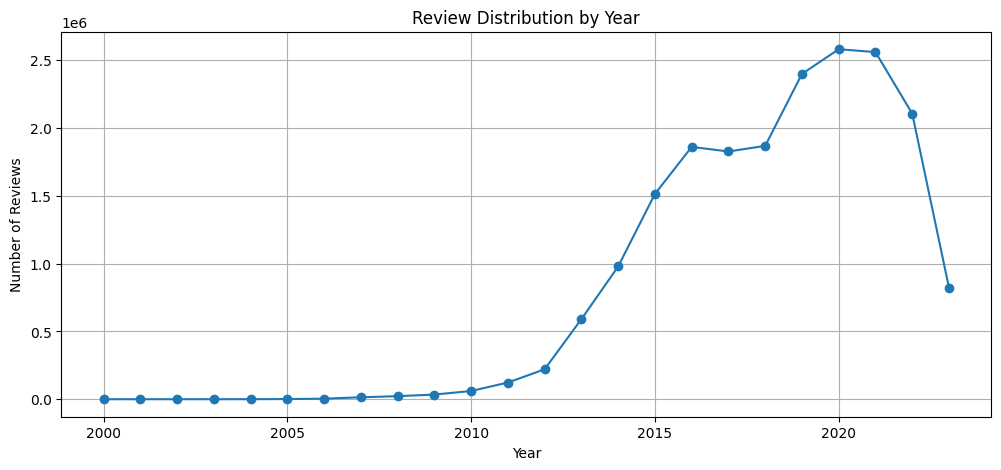

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    reviews_by_year_pd["review_year"],
    reviews_by_year_pd["count"],
    marker="o"
)

plt.title("Review Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.grid(True)

plt.savefig(
    "figures/fig_02_reviews_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The yearly distribution of reviews shows a consistent increase in customer review activity from 2000 onwards, with rapid growth beginning around 2013. Review volume continued to rise and reached its highest levels during 2020 and 2021, each recording over 2.5 million reviews.

A decline is observed for 2022 and 2023; however, the lower count for 2023 is likely influenced by the dataset covering only a partial year rather than reflecting an actual reduction in customer engagement.

### Conclusion

The dataset captures more than two decades of customer review activity and demonstrates substantial growth in user engagement over time. The strong concentration of reviews between 2019 and 2022 provides a rich foundation for temporal analysis, trend identification, and customer behavior studies.

## 9.2 Average Rating by Year

In [11]:
from pyspark.sql.functions import year, from_unixtime, col, avg
import pandas as pd

avg_rating_year = (
    reviews_df
    .withColumn(
        "review_year",
        year(from_unixtime(col("timestamp") / 1000))
    )
    .groupBy("review_year")
    .agg(
        avg("rating").alias("average_rating")
    )
    .orderBy("review_year")
)

avg_rating_year_pd = avg_rating_year.toPandas()

avg_rating_year_pd

,review_year,average_rating
0,2000,4.416667
1,2001,4.185714
2,2002,3.784615
3,2003,3.696429
4,2004,3.938567
5,2005,3.918161
6,2006,3.990620
7,2007,4.155046
8,2008,4.141400
9,2009,4.086427


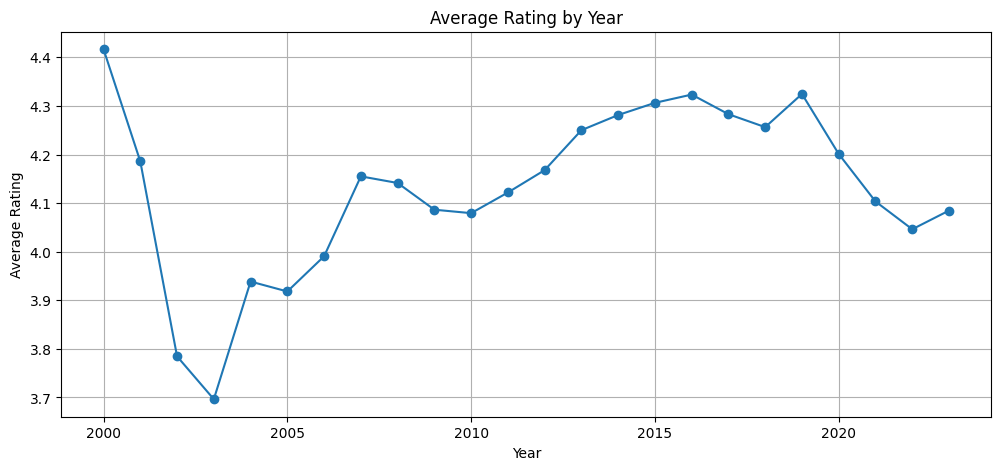

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    avg_rating_year_pd["review_year"],
    avg_rating_year_pd["average_rating"],
    marker="o"
)

plt.title("Average Rating by Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.grid(True)


plt.savefig(
    "figures/fig_03_avg_rating_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The average product rating remained consistently high throughout the observation period, generally ranging between **4.0 and 4.3 stars**. Although the earliest years (2000–2004) exhibit greater variation, these values are based on a relatively small number of reviews.

From 2013 onwards, the average rating stabilized above **4.2**, peaking at approximately **4.32** in 2016 and 2019. A slight decline is observed after 2020, but the average rating remained above **4.0**, indicating consistently positive customer feedback across the dataset.

### Conclusion

The temporal analysis indicates that customer satisfaction has remained consistently high over time. Despite substantial growth in review volume, the average product rating remained stable, suggesting a generally positive customer experience across the Sports & Outdoors product category.

## 9.3 Verified Purchase Trend

In [13]:
from pyspark.sql.functions import year, from_unixtime, col, avg, when

verified_year = (
    reviews_df
    .withColumn(
        "review_year",
        year(from_unixtime(col("timestamp") / 1000))
    )
    .groupBy("review_year")
    .agg(
        (
            avg(
                when(col("verified_purchase") == True, 1).otherwise(0)
            ) * 100
        ).alias("verified_percentage")
    )
    .orderBy("review_year")
)

verified_year_pd = verified_year.toPandas()

verified_year_pd

,review_year,verified_percentage
0,2000,4.166667
1,2001,21.428571
2,2002,18.461538
3,2003,27.678571
4,2004,18.771331
5,2005,29.150429
6,2006,38.583066
7,2007,46.278070
8,2008,50.170709
9,2009,61.894241


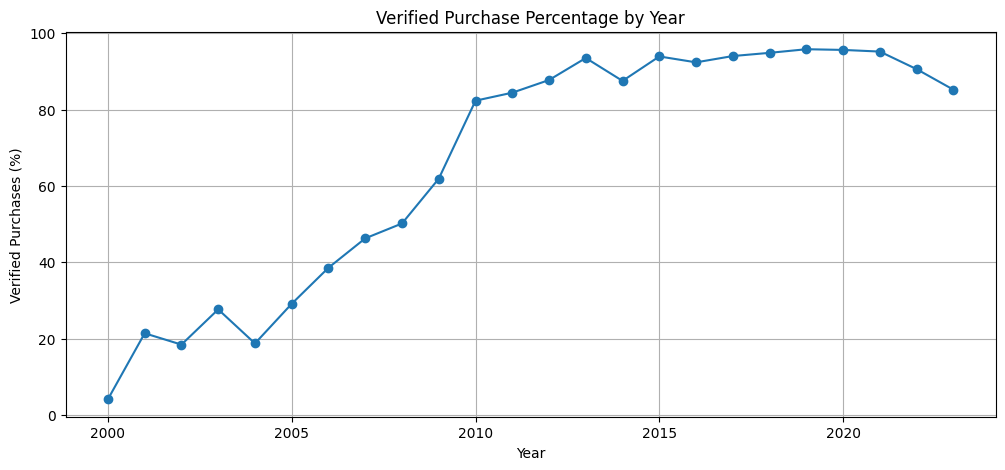

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    verified_year_pd["review_year"],
    verified_year_pd["verified_percentage"],
    marker="o"
)

plt.title("Verified Purchase Percentage by Year")
plt.xlabel("Year")
plt.ylabel("Verified Purchases (%)")
plt.grid(True)

plt.savefig(
    "figures/fig_04_verified_purchase.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The proportion of verified purchases increased substantially over time. Before 2010, verified purchase rates were relatively low and fluctuated due to the small number of reviews. From 2010 onwards, the percentage increased rapidly, exceeding **80%** and remaining consistently above **90%** for most years between 2013 and 2022.

A slight decline is observed in 2022 and 2023; however, the majority of reviews continue to originate from verified purchases, indicating a highly reliable review dataset.

### Conclusion

The increasing proportion of verified purchases demonstrates improved authenticity and credibility of customer reviews over time. Since the vast majority of recent reviews are associated with verified purchases, the dataset provides a trustworthy foundation for customer sentiment and product performance analysis.

## 9.4 Sentiment Distribution by Year

In [15]:
from pyspark.sql.functions import (
    year,
    from_unixtime,
    col,
    when
)
import pandas as pd

sentiment_year = (
    reviews_df
    .withColumn(
        "review_year",
        year(from_unixtime(col("timestamp") / 1000))
    )
    .withColumn(
        "sentiment",
        when(col("rating") >= 4, "Positive")
        .when(col("rating") == 3, "Neutral")
        .otherwise("Negative")
    )
    .groupBy("review_year", "sentiment")
    .count()
    .orderBy("review_year")
)

sentiment_year_pd = sentiment_year.toPandas()

sentiment_pivot = sentiment_year_pd.pivot(
    index="review_year",
    columns="sentiment",
    values="count"
).fillna(0)

sentiment_pivot

sentiment,Negative,Neutral,Positive
review_year,,,
2000,2,1,21
2001,10,7,53
2002,13,9,43
2003,28,8,76
2004,62,16,215
2005,248,99,936
2006,648,395,3008
2007,1726,1204,11498
2008,2827,1946,17780


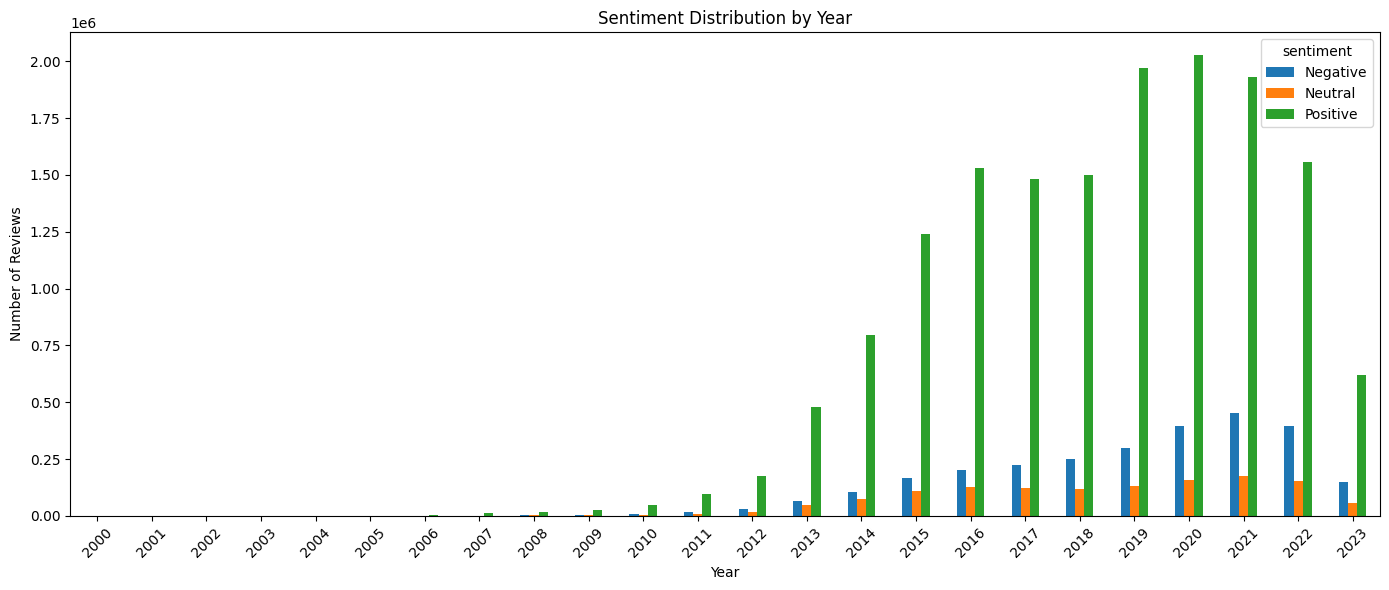

In [43]:
import matplotlib.pyplot as plt

sentiment_pivot.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Sentiment Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "figures/fig_05_sentiment_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Positive reviews consistently dominate the dataset across all years, accounting for the majority of customer feedback. As review volume increased over time, the number of positive, neutral, and negative reviews also increased; however, positive reviews grew at a substantially higher rate than the other sentiment categories.

The highest review activity occurred between 2019 and 2022, where positive reviews exceeded 1.5 million annually. Although negative and neutral reviews also increased during this period, they remained significantly lower than positive reviews, indicating sustained customer satisfaction over time.

### Conclusion

The year-wise sentiment distribution demonstrates a consistently positive customer perception of Sports & Outdoors products. The dominance of positive reviews throughout the dataset suggests high overall customer satisfaction and provides a reliable foundation for sentiment analysis and trend evaluation.

# 10. Product Analysis

This section examines product-level characteristics, including product popularity, customer ratings, category distribution, store distribution, and pricing patterns within the Sports & Outdoors dataset.

## 10.1 Top 10 Products by Number of Reviews

In [17]:
from pyspark.sql.functions import count, col

top_products = (
    reviews_df
    .groupBy("parent_asin")
    .agg(
        count("*").alias("review_count")
    )
    .join(
        metadata_df.select("parent_asin", "title"),
        on="parent_asin",
        how="left"
    )
    .select(
        "title",
        "review_count"
    )
    .orderBy(col("review_count").desc())
    .limit(10)
)

top_products_pd = top_products.toPandas()

top_products_pd

,title,review_count
0,"Fitbit Charge HR Wireless Activity Wristband (Tangerine, Large (6.2 - 7.6 in))",30369
1,"SoundAsleep Dream Series Luxury Air Mattress with ComfortCoil Technology & Built-in High Capacity Pump for Home & Camping- Double Height, Adjustable, Inflatable Blow Up, Portable - Twin Size",23638
2,BalanceFrom All Purpose 1/2-Inch Extra Thick High Density Anti-Tear Exercise Yoga Mat with Carrying Strap with Optional Yoga Blocks,20298
3,"Fitbit Charge 2 Heart Rate + Fitness Wristband, Teal, Small (US Version)",16590
4,"Fit Simplify Resistance Loop Exercise Bands with Instruction Guide and Carry Bag, Set of 5",15679
5,"Repel Umbrella The Original Portable Travel Umbrella - Umbrellas for Rain Windproof, Strong Compact Umbrella for Wind and Rain, Perfect Car Umbrella, Backpack, and On-the-Go",14565
6,Physix Gear Sport Modern,14478
7,"Vont LED Camping Lantern, LED Lanterns, Suitable Survival Kits for Hurricane, Emergency Light for Storm, Outages, Outdoor Portable Lanterns, Black, Collapsible, (Batteries Included)",14029
8,Howard Leight by Honeywell Impact Sport Sound Amplification Electronic Shooting Earmuff,13986
9,"Aegend Swim Goggles, Swimming Goggles No Leaking Full Protection Adult Men Women Youth",13856


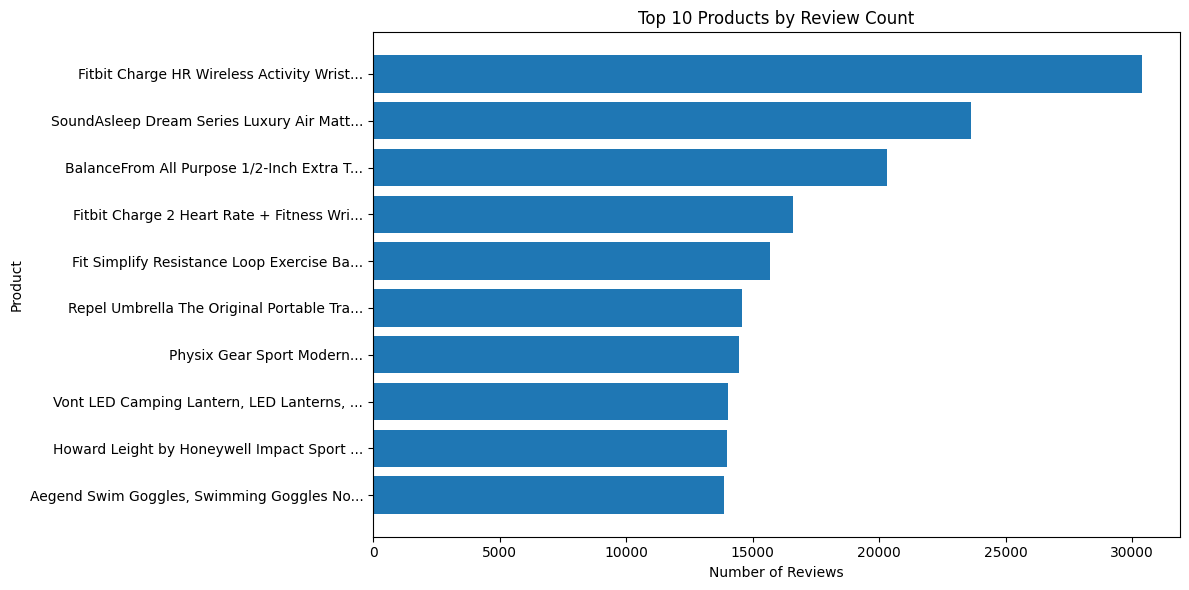

In [44]:
top_products_pd["short_title"] = (
    top_products_pd["title"]
    .str.slice(0, 40) + "..."
)

plt.figure(figsize=(12,6))

plt.barh(
    top_products_pd["short_title"],
    top_products_pd["review_count"]
)

plt.title("Top 10 Products by Review Count")
plt.xlabel("Number of Reviews")
plt.ylabel("Product")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "figures/fig_06_top_reviewed_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The review distribution indicates that a small number of products account for a disproportionately large volume of customer reviews. Fitness trackers, exercise equipment, camping accessories, travel gear, and swimming equipment are among the most frequently reviewed products in the Sports & Outdoors category.

The most reviewed product, the **Fitbit Charge HR Wireless Activity Wristband**, received over **30,000** customer reviews, followed by several other products with more than **13,000** reviews each.

### Conclusion

Customer engagement is concentrated around a relatively small group of highly popular products. These products provide valuable candidates for detailed customer sentiment analysis, recommendation systems, and product performance evaluation due to their substantial review volume.

## 10.2 Highest Rated Products (Minimum 100 Reviews)

In [ ]:
from pyspark.sql.functions import avg, count, col

top_rated_products = (
    reviews_df
    .groupBy("parent_asin")
    .agg(
        avg("rating").alias("average_rating"),
        count("*").alias("review_count")
    )
    .filter(col("review_count") >= 100)
    .join(
        metadata_df.select("parent_asin", "title"),
        on="parent_asin",
        how="left"
    )
    .select(
        "title",
        "average_rating",
        "review_count"
    )
    .orderBy(
        col("average_rating").desc(),
        col("review_count").desc()
    )
    .limit(10)
)

top_rated_products_pd = top_rated_products.toPandas()

top_rated_products_pd

### Observation

The highest-rated products all achieved average ratings above **4.95** while maintaining at least **100 customer reviews**, indicating consistently high customer satisfaction rather than isolated positive feedback. These products span multiple categories, including fitness equipment, outdoor gear, tactical accessories, sports equipment, and training products.

The top-ranked product, **Tacticon BattlePack Lite**, achieved an average rating of **4.98** based on **100** customer reviews, while the remaining products also maintained exceptionally high ratings with comparable review volumes.

### Conclusion

Applying a minimum review threshold identifies products that combine high customer satisfaction with a meaningful level of customer engagement. These products represent strong candidates for best-selling product analysis, recommendation systems, and benchmarking against lower-performing products.

## 10.3 Lowest Rated Products (Minimum 100 Reviews)

In [21]:
from pyspark.sql.functions import avg, count, col

lowest_rated_products = (
    reviews_df
    .groupBy("parent_asin")
    .agg(
        avg("rating").alias("average_rating"),
        count("*").alias("review_count")
    )
    .filter(col("review_count") >= 100)
    .join(
        metadata_df.select("parent_asin", "title"),
        on="parent_asin",
        how="left"
    )
    .select(
        "title",
        "average_rating",
        "review_count"
    )
    .orderBy(
        col("average_rating").asc(),
        col("review_count").desc()
    )
    .limit(10)
)

lowest_rated_products_pd = lowest_rated_products.toPandas()

lowest_rated_products_pd

,title,average_rating,review_count
0,"FFOK Golf Training Mat for Swing Detection Batting, Premium Golf Impact Mat, Path Feedback Golf Practice Mats, Advanced Golf Hitting Mat for Indoor/Outdoor, Golf Training Aid Equipment, Green",1.246154,195
1,Schwinn Air Driver 1100 Floor Pump with 5 in 1,1.344000,125
2,"COOWOO Resistance Bands Set, Exercise Bands with Door Anchor, Handles, Waterproof Carry Bag, Legs Ankle Straps for Resistance Training, Physical Therapy, Home Workouts",1.682759,145
3,Glow in The Dark Outdoor Basketball Net Nylon Glowing Basketball Hoop Rim Net All Weather Thick Replacement Standard Size Net Rim Hoop Heavy Duty,1.697479,119
4,ProForm Le Tour De France,1.742424,132
5,"""Safety First"" Splash-N-Swim Child-Sized Swim Masks Goggles Assortment! (Set of 4)",1.745098,204
6,"IdeaWorks Kool-Down EVAPORATIVE Cooler, Black",1.747899,119
7,SKLZ Bullet Ball -Baseball Pitching Speed Sensor,1.751748,572
8,What Kids Want Superhero Inflatable Punching Bop Bag Exercise Toy (2 Styles),1.792079,101
9,Skechers Go Walk Activity Tracker/Sleep Monitor,1.828125,128


### Observation

The lowest-rated products recorded average ratings between **1.25** and **1.83** despite receiving more than **100 customer reviews**, indicating consistently poor customer satisfaction rather than isolated negative experiences. The identified products span multiple categories, including golf equipment, fitness accessories, sports toys, wearable devices, and outdoor products.

The **FFOK Golf Training Mat for Swing Detection** received the lowest average rating of **1.25** based on **195** reviews, while the **SKLZ Bullet Ball Baseball Pitching Speed Sensor** accumulated over **570** reviews despite maintaining a low average rating, suggesting substantial customer interest but poor overall satisfaction.

### Conclusion

Products with consistently low ratings and a substantial number of reviews highlight areas where customer expectations were not met. These products are valuable candidates for root cause analysis, quality improvement initiatives, and comparative studies against highly rated products.

## 10.4 Product Average Rating Distribution

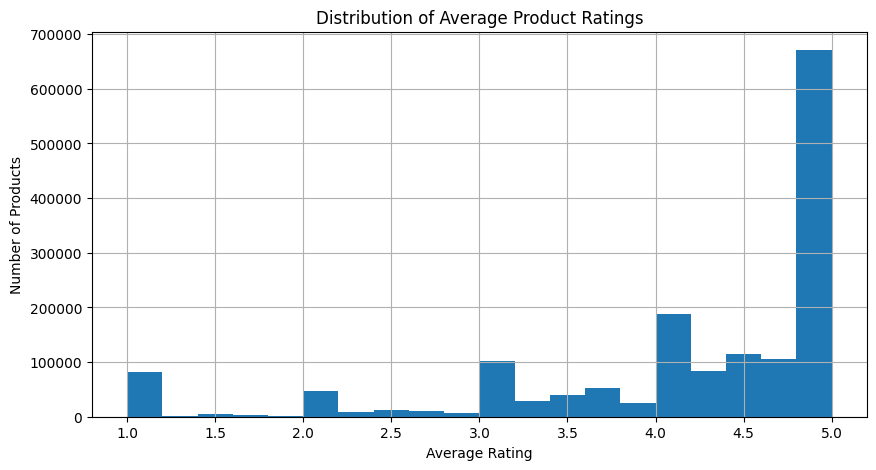

In [46]:
from pyspark.sql.functions import avg
import matplotlib.pyplot as plt

product_avg_rating = (
    reviews_df
    .groupBy("parent_asin")
    .agg(
        avg("rating").alias("average_rating")
    )
)

product_avg_rating_pd = product_avg_rating.toPandas()

plt.figure(figsize=(10,5))

plt.hist(
    product_avg_rating_pd["average_rating"],
    bins=20
)

plt.title("Distribution of Average Product Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Products")

plt.grid(True)

import os
os.makedirs("figures", exist_ok=True)

import os
os.makedirs("figures", exist_ok=True)

plt.savefig(
    "figures/fig_07_product_rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



### Observation

The distribution of average product ratings is heavily concentrated between **4.0 and 5.0 stars**, indicating that most products receive favorable customer feedback. A large proportion of products have average ratings close to **5.0**, while relatively few products fall below **3.0**.

The distribution exhibits a left-skewed pattern, where low-rated products are comparatively rare but form a long tail extending toward ratings near **1.0**.

### Conclusion

The overall rating distribution suggests that customer satisfaction within the Sports & Outdoors category is generally high. Although a small number of products receive consistently poor ratings, the majority maintain strong customer approval, making the dataset well suited for product performance analysis and recommendation applications.

## 10.5 Top Product Categories

In [23]:
from pyspark.sql.functions import count, col
import matplotlib.pyplot as plt

top_categories = (
    metadata_df
    .groupBy("main_category")
    .agg(
        count("*").alias("product_count")
    )
    .orderBy(col("product_count").desc())
    .limit(10)
)

top_categories_pd = top_categories.toPandas()

top_categories_pd

,main_category,product_count
0,Sports & Outdoors,870267
1,AMAZON FASHION,259564
2,NaN,249954
3,Amazon Home,74995
4,Automotive,45629
5,Tools & Home Improvement,25580
6,Toys & Games,12477
7,Industrial & Scientific,9081
8,Pet Supplies,7999
9,Cell Phones & Accessories,6905


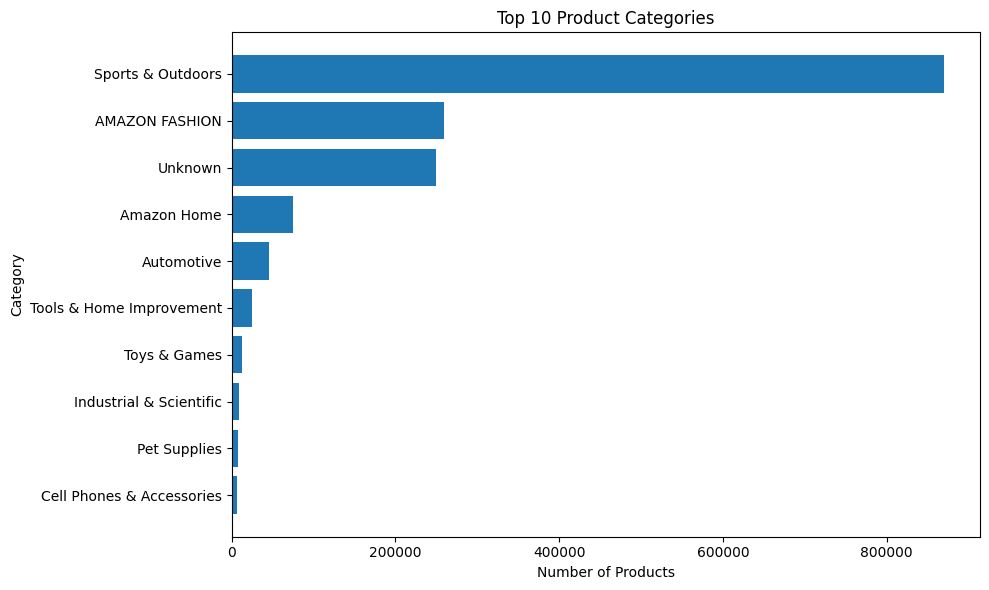

In [47]:
top_categories_pd["main_category"] = (
    top_categories_pd["main_category"]
    .fillna("Unknown")
)

plt.figure(figsize=(10,6))

plt.barh(
    top_categories_pd["main_category"],
    top_categories_pd["product_count"]
)

plt.title("Top 10 Product Categories")
plt.xlabel("Number of Products")
plt.ylabel("Category")

plt.gca().invert_yaxis()

plt.tight_layout()

import os
os.makedirs("figures", exist_ok=True)

plt.savefig(
    "figures/fig_08_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.show()

### Observation

The Sports & Outdoors category contains the largest number of products, accounting for over **870,000** product records. Other prominent categories include **Amazon Fashion**, **Amazon Home**, **Automotive**, and **Tools & Home Improvement**.

Approximately **250,000** products do not contain a value for the `main_category` attribute and are classified as **Unknown**, highlighting a notable amount of missing category information in the metadata.

### Conclusion

The product catalog is heavily concentrated within the Sports & Outdoors category while also containing products from several related categories. The presence of a substantial number of missing category values should be considered during downstream analysis and preprocessing.

## 10.6 Top Stores by Product Count

In [26]:
from pyspark.sql.functions import count, col, coalesce, lit

top_stores = (
    metadata_df
    .withColumn(
        "store",
        coalesce(col("store"), lit("Unknown"))
    )
    .groupBy("store")
    .agg(
        count("*").alias("product_count")
    )
    .orderBy(col("product_count").desc())
    .limit(10)
)

top_stores_pd = top_stores.toPandas()

top_stores_pd

,store,product_count
0,Unknown,37257
1,adidas,16327
2,WinCraft,15917
3,New Era,11442
4,'47,10858
5,Outerstuff,10026
6,Nike,8791
7,Reebok,7986
8,Majestic,7772
9,FOCO,7551


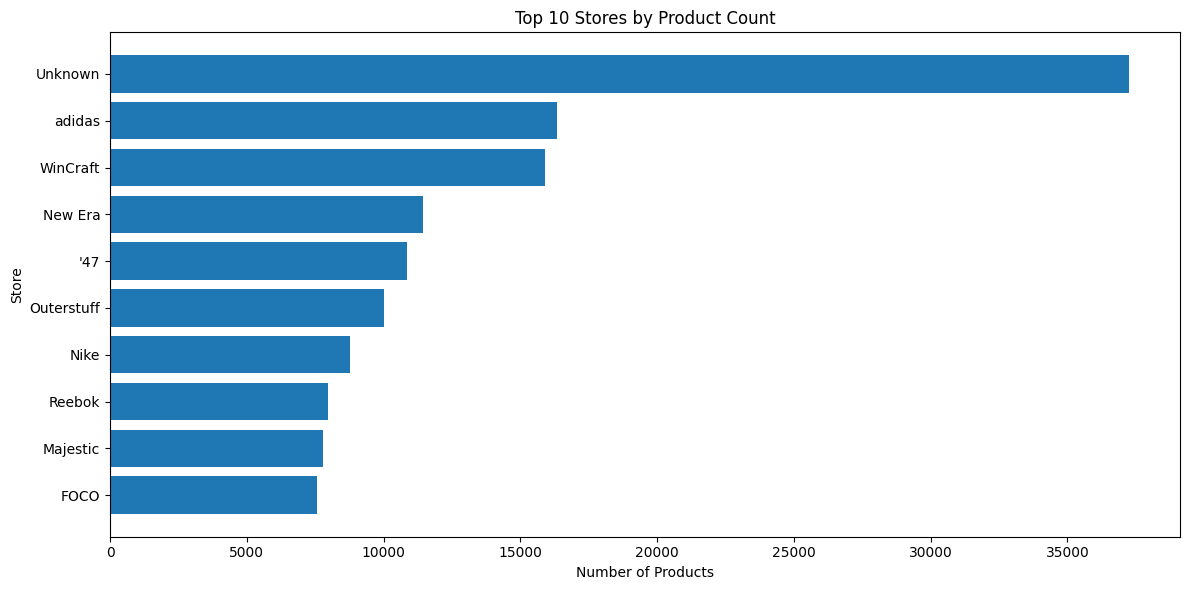

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.barh(
    top_stores_pd["store"],
    top_stores_pd["product_count"]
)

plt.title("Top 10 Stores by Product Count")
plt.xlabel("Number of Products")
plt.ylabel("Store")

plt.gca().invert_yaxis()

plt.tight_layout()

import os
os.makedirs("figures", exist_ok=True)

plt.savefig(
    "figures/fig_09_store_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

### Observation

The store-level analysis shows that a significant number of products have missing store information, represented as **Unknown**. Among the identified stores, **adidas**, **WinCraft**, **New Era**, **'47**, and **Outerstuff** contribute the largest number of products within the Sports & Outdoors dataset.

The presence of several well-established sports brands indicates that the dataset covers a diverse range of manufacturers and retailers.

### Conclusion

The product catalog is distributed across numerous stores and brands, although a considerable proportion of records lack store information. Well-represented brands provide sufficient data for comparative analyses, while missing store values should be considered during downstream preprocessing.

## 10.7 Price Distribution

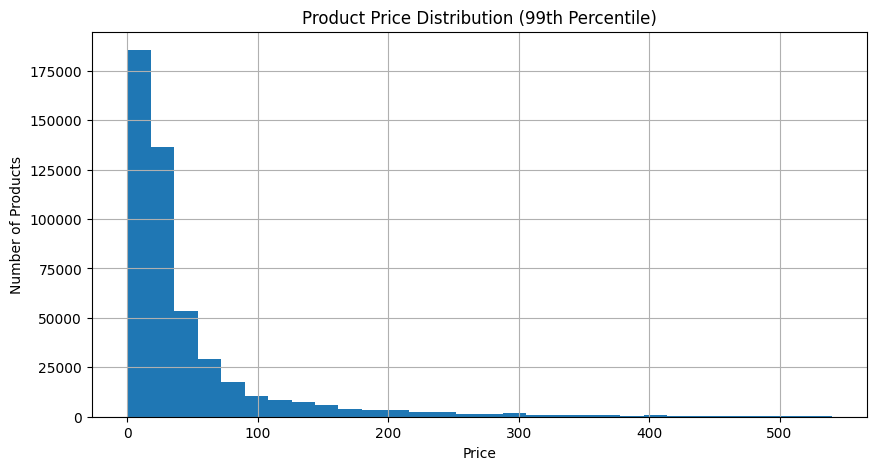

In [49]:
from pyspark.sql.functions import expr
import matplotlib.pyplot as plt

price_pd = (
    metadata_df
    .select(expr("try_cast(price AS DOUBLE) AS price"))
    .filter("price IS NOT NULL")
    .toPandas()
)

# Remove extreme outliers for visualization
price_plot = price_pd[price_pd["price"] <= price_pd["price"].quantile(0.99)]

plt.figure(figsize=(10,5))

plt.hist(
    price_plot["price"],
    bins=30
)

plt.title("Product Price Distribution (99th Percentile)")
plt.xlabel("Price")
plt.ylabel("Number of Products")

plt.grid(True)

import os
os.makedirs("figures", exist_ok=True)

plt.savefig(
    "figures/fig_10_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

### Observation

The product price distribution is highly right-skewed, with the majority of products priced at the lower end of the range. Most products are concentrated below **$50**, while the number of products decreases progressively as price increases.

A small number of high-priced products create a long right tail in the distribution. For visualization purposes, values above the **99th percentile** were excluded to improve readability without affecting the underlying dataset.

### Conclusion

The Sports & Outdoors product catalog is primarily composed of low- to moderately-priced products, with relatively few premium-priced items. This pricing pattern is typical of large online retail marketplaces and provides a useful basis for pricing and customer purchasing behavior analysis.

## 10.8 Average Price by Category

In [29]:
from pyspark.sql.functions import expr, avg, count, col, coalesce, lit
import matplotlib.pyplot as plt

avg_price_category = (
    metadata_df
    .withColumn(
        "main_category",
        coalesce(col("main_category"), lit("Unknown"))
    )
    .withColumn(
        "price_double",
        expr("try_cast(price AS DOUBLE)")
    )
    .filter(col("price_double").isNotNull())
    .groupBy("main_category")
    .agg(
        avg("price_double").alias("average_price"),
        count("*").alias("product_count")
    )
    .filter(col("product_count") >= 100)
    .orderBy(col("average_price").desc())
    .limit(10)
)

avg_price_category_pd = avg_price_category.toPandas()

avg_price_category_pd

,main_category,average_price,product_count
0,Camera & Photo,167.876241,564
1,Musical Instruments,92.947934,121
2,Collectibles & Fine Art,70.714667,135
3,Sports Collectibles,68.701237,752
4,Sports & Outdoors,68.044827,273947
5,All Electronics,61.991997,1437
6,Unknown,60.700133,49916
7,Toys & Games,59.108351,5362
8,Industrial & Scientific,55.081220,4688
9,Grocery,51.217719,399


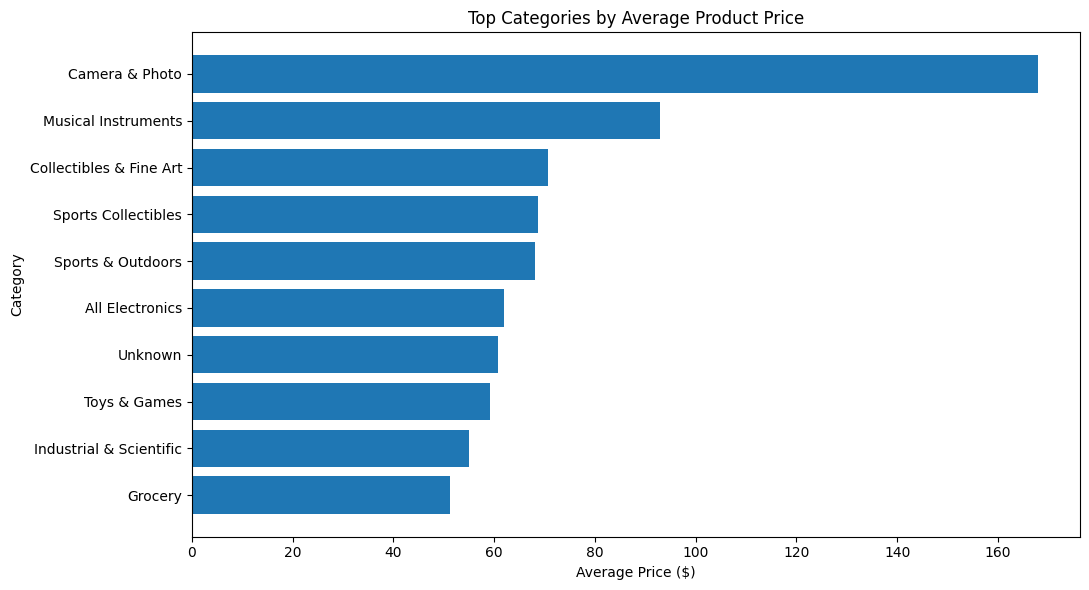

In [50]:
plt.figure(figsize=(11,6))

plt.barh(
    avg_price_category_pd["main_category"],
    avg_price_category_pd["average_price"]
)

plt.title("Top Categories by Average Product Price")
plt.xlabel("Average Price ($)")
plt.ylabel("Category")

plt.gca().invert_yaxis()

plt.tight_layout()
import os
os.makedirs("figures", exist_ok=True)

plt.savefig(
    "figures/fig_11_avg_price_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

### Observation

The average product price varies considerably across product categories. **Camera & Photo** products have the highest average price (approximately **$167.88**), followed by **Musical Instruments** and **Collectibles & Fine Art**. Within the Sports & Outdoors category, the average product price is approximately **$68.04**, placing it among the higher-priced categories in the dataset.

The variation in average prices reflects differences in product complexity, intended use, and market positioning across categories.

### Conclusion

Product pricing differs substantially across categories, with specialized equipment generally commanding higher average prices than consumer-oriented products. The Sports & Outdoors category combines a large product catalog with a relatively high average selling price, making it an important segment for pricing, sales, and customer behavior analysis.

# 11. Review Analysis

This section examines characteristics of customer reviews, including review length, helpful votes, and overall sentiment, to better understand customer engagement and review quality.

## 11.1 Review Length Analysis

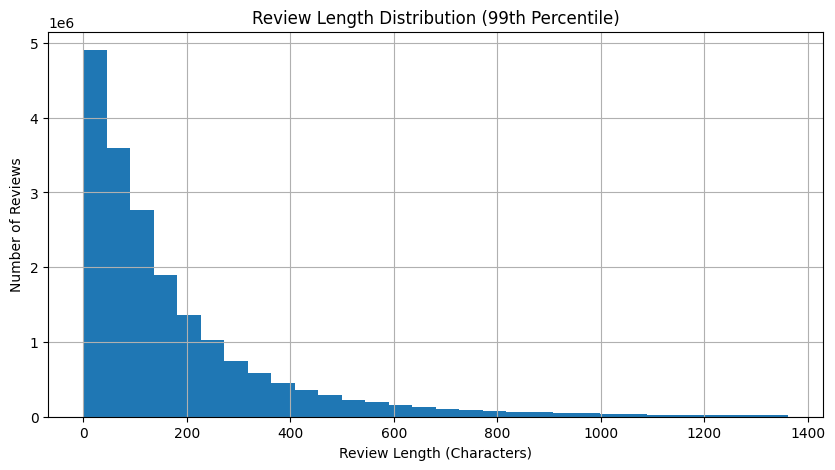

In [51]:
review_plot = review_length_pd[
    review_length_pd["review_length"]
    <= review_length_pd["review_length"].quantile(0.99)
]

plt.figure(figsize=(10,5))

plt.hist(
    review_plot["review_length"],
    bins=30
)

plt.title("Review Length Distribution (99th Percentile)")
plt.xlabel("Review Length (Characters)")
plt.ylabel("Number of Reviews")

plt.grid(True)

import os
os.makedirs("figures", exist_ok=True)

plt.savefig(
    "figures/fig_12_review_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

In [32]:
review_length_pd.describe()

,review_length
count,1.959517e+07
mean,1.960862e+02
std,2.978401e+02
min,0.000000e+00
25%,4.500000e+01
50%,1.110000e+02
75%,2.330000e+02
max,3.003500e+04


### Observation

The review length distribution is highly right-skewed, with most reviews being relatively short and a small proportion containing very long textual feedback. The median review length is **111 characters**, while the average review length is approximately **196 characters**, indicating that a limited number of lengthy reviews increase the overall mean.

The maximum review length exceeds **30,000 characters**, demonstrating the presence of a small number of exceptionally detailed reviews within the dataset.

### Conclusion

Most customers provide concise reviews, while a smaller subset contributes detailed textual feedback. This variation in review length provides a rich source of information for downstream natural language processing tasks such as sentiment analysis, text summarization, and keyword extraction.

## 11.2 Helpful Vote Analysis

In [34]:
from pyspark.sql.functions import col
import matplotlib.pyplot as plt

helpful_pd = (
    reviews_df
    .select("helpful_vote")
    .toPandas()
)

helpful_pd.describe()

,helpful_vote
count,1.959517e+07
mean,1.044607e+00
std,1.490053e+01
min,-3.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,2.878100e+04


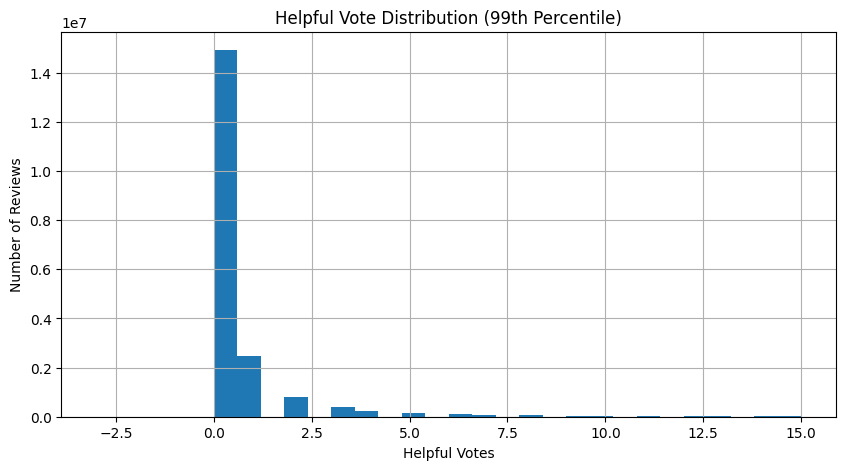

In [52]:
helpful_plot = helpful_pd[
    helpful_pd["helpful_vote"]
    <= helpful_pd["helpful_vote"].quantile(0.99)
]

plt.figure(figsize=(10,5))

plt.hist(
    helpful_plot["helpful_vote"],
    bins=30
)

plt.title("Helpful Vote Distribution (99th Percentile)")
plt.xlabel("Helpful Votes")
plt.ylabel("Number of Reviews")

plt.grid(True)

import os
os.makedirs("figures", exist_ok=True)

plt.savefig(
    "figures/fig_13_helpful_votes_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

### Observation

The helpful vote distribution is highly right-skewed. While the average review receives approximately **1.04 helpful votes**, the median and 75th percentile are both **0**, indicating that the majority of reviews receive no helpful votes.

A small number of reviews accumulate exceptionally high helpful vote counts, with the maximum reaching **28,781** votes. These highly engaged reviews create a long right tail in the distribution and substantially increase the overall average.

### Conclusion

Most customer reviews receive little or no community feedback, whereas a relatively small number of reviews become highly influential. Helpful vote counts can therefore serve as an effective indicator for identifying informative reviews, prioritizing content, and supporting downstream recommendation and ranking systems.

## 11.3 Overall Sentiment Distribution

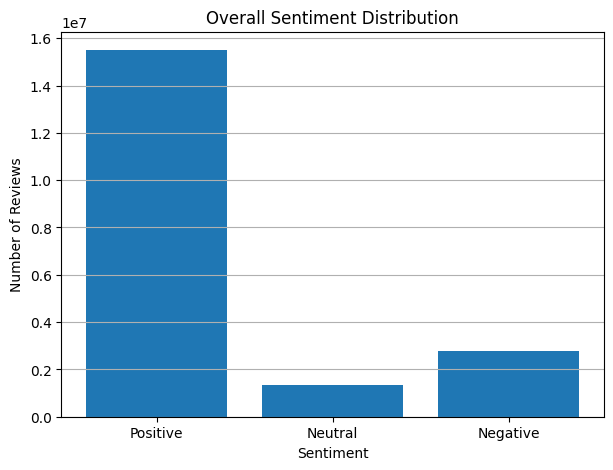

,sentiment,review_count
0,Positive,15500168
1,Neutral,1324911
2,Negative,2770091


In [53]:
from pyspark.sql.functions import when, count
import matplotlib.pyplot as plt

overall_sentiment = (
    reviews_df
    .withColumn(
        "sentiment",
        when(col("rating") >= 4, "Positive")
        .when(col("rating") == 3, "Neutral")
        .otherwise("Negative")
    )
    .groupBy("sentiment")
    .agg(count("*").alias("review_count"))
)

overall_sentiment_pd = overall_sentiment.toPandas()

plt.figure(figsize=(7,5))

plt.bar(
    overall_sentiment_pd["sentiment"],
    overall_sentiment_pd["review_count"]
)

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.grid(axis="y")
import os
os.makedirs("figures", exist_ok=True)

plt.savefig(
    "figures/fig_14_overall_sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

overall_sentiment_pd

### Observation

The overall sentiment distribution is heavily dominated by positive reviews. Out of approximately **19.6 million** customer reviews, **15.50 million** (≈79.1%) are classified as positive, **2.77 million** (≈14.1%) as negative, and **1.32 million** (≈6.8%) as neutral.

The substantial difference between positive and negative reviews indicates that customers generally report favorable experiences with Sports & Outdoors products.

### Conclusion

The sentiment distribution demonstrates consistently positive customer feedback across the dataset. The predominance of positive reviews makes the dataset well suited for sentiment analysis, recommendation systems, customer satisfaction studies, and product performance evaluation.

# 12. Sampling Validation

This section validates the sampling strategy used for downstream analysis. A stratified sampling approach was adopted to ensure balanced representation of review data across different years while reducing the dataset size for efficient processing.

## 12.1 Population Distribution by Year

In [37]:
from pyspark.sql.functions import year, from_unixtime, col, count
import pandas as pd

population_year = (
    reviews_df
    .withColumn(
        "review_year",
        year(from_unixtime(col("timestamp") / 1000))
    )
    .groupBy("review_year")
    .agg(
        count("*").alias("population_reviews")
    )
    .filter(col("review_year") >= 2014)
    .orderBy("review_year")
)

population_year_pd = population_year.toPandas()

population_year_pd

,review_year,population_reviews
0,2014,979673
1,2015,1514200
2,2016,1861396
3,2017,1827544
4,2018,1868974
5,2019,2399675
6,2020,2581850
7,2021,2560561
8,2022,2106492
9,2023,822098


### Observation

The yearly review distribution indicates that every year from **2014 to 2023** contains substantially more than **10,000** customer reviews. This ensures that an equal number of reviews can be sampled from each year without introducing sampling limitations or exhausting the available population.

### Conclusion

The review population is sufficiently large across all selected years, making stratified sampling both feasible and statistically appropriate for creating a balanced analytical dataset.

## 12.2 Sampling Strategy

To support downstream natural language processing and machine learning tasks, a stratified sampling strategy will be applied during the Bronze-to-Silver ETL process.

After merging the Reviews and Metadata datasets, the merged dataset will be filtered for reviews between 2014 and 2023. A balanced sample of 100,000 reviews will then be created by randomly selecting 10,000 reviews from each year using stratified sampling.

This approach ensures equal temporal representation while significantly reducing computational cost for subsequent feature engineering, embedding generation, and model development.

### Conclusion

The sampling process will be performed after the Silver dataset has been created to ensure that all review and product attributes are available. Performing sampling on the merged dataset provides a representative and balanced analytical dataset for downstream processing.

# 13. Business Insights & Summary

## 13.1 Key Findings

### Dataset Overview

- The Sports & Outdoors dataset contains approximately **19.6 million** customer reviews covering over **1.58 million** unique products.
- The dataset spans more than **two decades** of customer activity, from **2000 to 2023**, providing extensive historical coverage.

### Data Quality

- The datasets demonstrate strong structural integrity with no orphan review records after relationship validation.
- Missing values are primarily limited to optional descriptive attributes such as price, videos, and product descriptions.
- Product metadata maintains a unique `parent_asin` for each product, while duplicate review records are limited and can be addressed during Silver layer preprocessing.

### Customer Behaviour

- Customer reviews increased significantly over time, with the highest review activity occurring between **2019 and 2022**.
- Approximately **79%** of all reviews are positive, indicating consistently favorable customer experiences.
- More than **90%** of recent reviews originate from verified purchases, increasing the reliability of customer feedback.

### Product Insights

- Customer engagement is concentrated among a relatively small number of highly popular products.
- Most products maintain average ratings above **4.0**, demonstrating strong customer satisfaction across the category.
- Product prices are predominantly concentrated in the lower price ranges, with only a small proportion of premium-priced products.

### Review Characteristics

- Most customer reviews are concise, with a median length of **111 characters**.
- The majority of reviews receive no helpful votes, while a small number accumulate exceptionally high community engagement.

## 13.2 Overall Conclusion

The exploratory data analysis demonstrates that the Amazon Sports & Outdoors dataset is large, diverse, and well suited for large-scale analytical workloads. The dataset exhibits strong referential integrity, high review authenticity, and consistently positive customer sentiment while containing only a limited number of manageable data quality issues.

Based on the findings of this analysis, the dataset is considered suitable for downstream ETL processing, feature engineering, natural language processing, sentiment analysis, and machine learning applications. The next phase of the project will focus on constructing the Silver layer by cleaning, transforming, and integrating the Reviews and Metadata datasets into a unified analytical dataset.

In [ ]:
D